# Lección 05 — Jupyter Notebooks

**Regla de oro:** *Explorar en notebooks, ejecutar en scripts.*

Este notebook cubre los 3 ejercicios de la lección:
1. `%timeit` — list comprehension vs NumPy
2. DataFrame + plot (verificar con Restart & Run All)
3. Patrones clave: memoria y trampas comunes

## Ejercicio 1 — `%timeit`: List comprehension vs NumPy

- `%timeit` → ejecuta **muchas veces** y promedia. Ideal para microbenchmarks.
- `%%time` → ejecuta la celda **una sola vez**. Ideal para entrenamientos largos.

In [1]:
import numpy as np

# List comprehension: 100k elementos
%timeit [x**2 for x in range(100_000)]

5.25 ms ± 138 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [2]:
# NumPy: misma operación vectorizada
%timeit np.arange(100_000)**2

42.3 μs ± 2.67 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [3]:
import time

# Medición manual para ver el speedup real
start = time.perf_counter()
_ = [x**2 for x in range(100_000)]
list_time = time.perf_counter() - start

start = time.perf_counter()
_ = np.arange(100_000)**2
numpy_time = time.perf_counter() - start

print(f"List comprehension: {list_time*1000:.2f} ms")
print(f"NumPy:              {numpy_time*1000:.2f} ms")
print(f"Speedup:            {list_time/numpy_time:.0f}x")

List comprehension: 4.75 ms
NumPy:              1.01 ms
Speedup:            5x


## Ejercicio 2 — DataFrame + Plot

Este notebook debe funcionar ejecutado **de arriba a abajo** sin errores.  
Verifica con: `Kernel > Restart & Run All`

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "modelo": ["Linear Regression", "Random Forest", "Neural Network", "XGBoost"],
    "accuracy": [0.72, 0.89, 0.94, 0.91],
    "tiempo_train_s": [0.1, 2.3, 45.6, 8.2],
})

# En Jupyter, 'df' al final de celda renderiza tabla HTML
df

,modelo,accuracy,tiempo_train_s
0,Linear Regression,0.72,0.1
1,Random Forest,0.89,2.3
2,Neural Network,0.94,45.6
3,XGBoost,0.91,8.2


In [5]:
print(f"Mejor modelo:      {df.loc[df['accuracy'].idxmax(), 'modelo']}")
print(f"Modelo más rápido: {df.loc[df['tiempo_train_s'].idxmin(), 'modelo']}")

Mejor modelo:      Neural Network
Modelo más rápido: Linear Regression


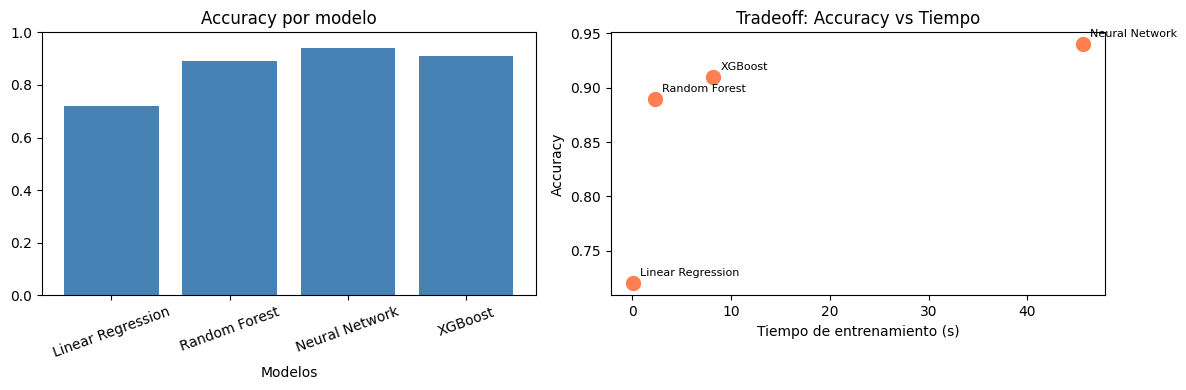

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras: accuracy por modelo
axes[0].bar(df["modelo"], df["accuracy"], color="steelblue")
axes[0].set_xlabel("Modelos")
axes[0].set_title("Accuracy por modelo")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

# Scatter: tradeoff accuracy vs tiempo
axes[1].scatter(df["tiempo_train_s"], df["accuracy"], s=100, color="coral")
for _, row in df.iterrows():
    axes[1].annotate(row["modelo"], (row["tiempo_train_s"], row["accuracy"]),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xlabel("Tiempo de entrenamiento (s)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Tradeoff: Accuracy vs Tiempo")

plt.tight_layout()
plt.show()

## Ejercicio 3 — Memoria y trampas comunes

In [7]:
# Los arrays crecen rápido — el kernel acumula todo en memoria
small  = np.random.randn(1_000)
medium = np.random.randn(100_000)
large  = np.random.randn(10_000_000)

for nombre, arr in [("1K", small), ("100K", medium), ("10M", large)]:
    print(f"Array {nombre:>4s}: {arr.nbytes / 1e6:.2f} MB")

Array   1K: 0.01 MB
Array 100K: 0.80 MB
Array  10M: 80.00 MB


In [8]:
import gc

# Liberar memoria explícitamente cuando ya no la necesitas
del large
gc.collect()
print("'large' eliminado de memoria.")

'large' eliminado de memoria.


## Resumen — Trampas y cuándo usar cada uno

| Trampa | Síntoma | Fix |
|--------|---------|-----|
| Ejecución fuera de orden | Funciona solo en tu máquina | `Kernel > Restart & Run All` |
| Estado oculto | Variable existe aunque borraste la celda | Reiniciar kernel regularmente |
| Memory leak | El proceso crece sin parar | `del var` + `gc.collect()` |

| Usa **notebook** para... | Usa **script** para... |
|--------------------------|------------------------|
| Explorar datos | Pipelines de entrenamiento |
| Prototipar modelos | Utilidades reutilizables |
| Visualizar resultados | Código en producción |
| Explicar tu trabajo | Código con schedule |